In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import huracanpy
from cartopy.crs import EqualEarth
from huracanpy.plot import fancyline
import seaborn as sns
from tc_helpers import *

In [2]:
tracks = load_syclops()

10kmCoMorph TC tracks loaded successfully
10kmGAL TC tracks loaded successfully
5kmCoMorph TC tracks loaded successfully
5kmRAL TC tracks loaded successfully


/home/users/l_grant/.conda/envs/hk26_env/lib/python3.14/site-packages/huracanpy/_data/ibtracs.py:119: UserWarning: This offline function loads a light version of IBTrACS which is embedded within the package, based on a file produced manually by the developers.
 It was last updated on the 15th Nov 2024, based on the IBTrACS file at that date.
 It contains only data from 1980 up to the last year with no provisional tracks. All spur tracks were removed. Only 6-hourly time steps were kept.
  warnings.warn(


JTWC tracks loaded successfully


In [6]:
for name,ds in tracks.items():
    ds_tmp = compute_intensification_rate(ds, var='sfcwind_max', timedelta=6)
    tracks[name] = compute_intensification_rate(ds_tmp, var='psl_min', timedelta=6)

24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr


In [7]:
cm5 = tracks['5kmCoMorph']
test_track = cm5.where(cm5.track_id == 139, drop=True)
test_track.sfcwind_max.max()

<xarray.DataArray 'sfcwind_max' ()> Size: 8B
array(129.69759528)

Peak surface wind speed: <xarray.DataArray 'sfcwind_max' ()> Size: 8B
array(129.69759528) knots


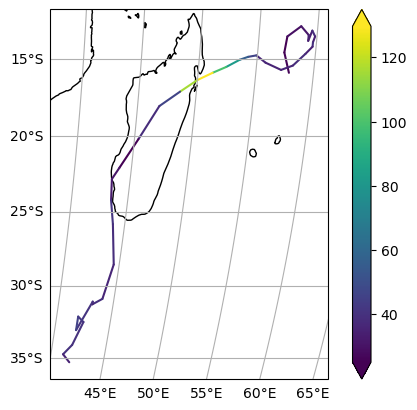

In [8]:
# Set up a figure with a cartopy projection
ax = plt.axes(projection=EqualEarth())

# Show surface wind speed with a colourscale
lc = fancyline(
    test_track.lon,
    test_track.lat,
    test_track.sfcwind_max,
    vmax=test_track.sfcwind_max.max(),
    vmin=25,
    ax=ax,
)

plt.colorbar(lc, extend="both")
ax.coastlines()
ax.gridlines(draw_labels=["left", "bottom"])
print(f'Peak surface wind speed: {test_track.sfcwind_max.max()} knots')

<Axes: xlabel='time_from_wind_max', ylabel='Min SLP [hPa]'>

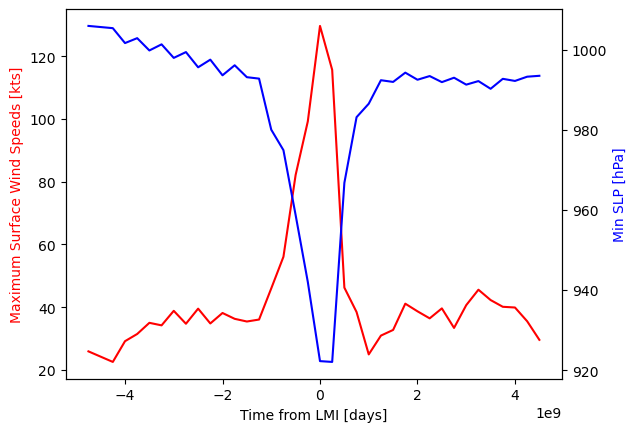

In [10]:
# Time series of this intense storm: 
# Compute times from extremum
test_track["time_from_wind_max"] = test_track.hrcn.get_time_from_apex(
    intensity_var_name="sfcwind_max", stat="max") / (24*3600)

test_track['time_from_slp_min'] = test_track.hrcn.get_time_from_apex(
    intensity_var_name="psl_min", stat="min") / (24*3600)

# Plot with seaborn
fig, ax = plt.subplots(1, sharex=True)
ax.set_ylabel('Maximum Surface Wind Speeds [kts]', color='r')
ax.set_xlabel('Time from LMI [days]')
ax2 = ax.twinx()
ax2.set_ylabel('Min SLP [hPa]', color='b')
# Wind lifecycle
sns.lineplot(data=test_track, x="time_from_wind_max", y="sfcwind_max", ax=ax, color= 'r')
sns.lineplot(data=test_track, x='time_from_wind_max', y='psl_min', ax=ax2, color='b')

SECTION A: BASIC STORM STATISTICS + PLOTS
1) Genesis locations
2) Seasonal cycle of genesis
3) LM24hr + LMI locations
4) Wind-pressure relationship
5) Intensification rate distributions

In [19]:
# More systematically compare intensification rate distributions between model configs next.
# Case studies where we compare the strongest storms in each model config?

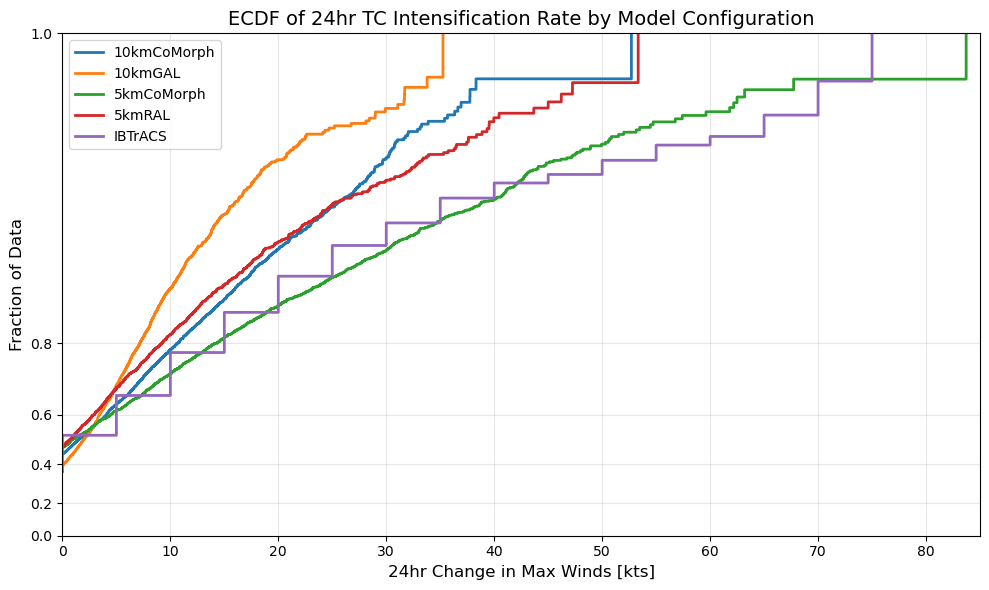

In [51]:
# Single ECDF plot with all model configs
fig, ax = plt.subplots(figsize=(10, 6))

for name, ds in tracks.items():
    # Strip nans from rates 
    rates = ds.wind_ir_24hr.dropna(dim='record')
    # 
    # Plot ECDF
    ax.ecdf(rates, label=name, linewidth=2)

ax.set_xlabel('24hr Change in Max Winds [kts]', fontsize=12)
ax.set_ylabel('Fraction of Data', fontsize=12)
ax.set_title('ECDF of 24hr TC Intensification Rate by Model Configuration', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0,85])
# ax.set_xscale('log')
ax.set_yscale('function', functions=(lambda x: 1- (1-x)**0.3, lambda x: 1 - (1- x)**(1/0.3)))
ax.set_ylim([0,1])
plt.tight_layout()
plt.show()

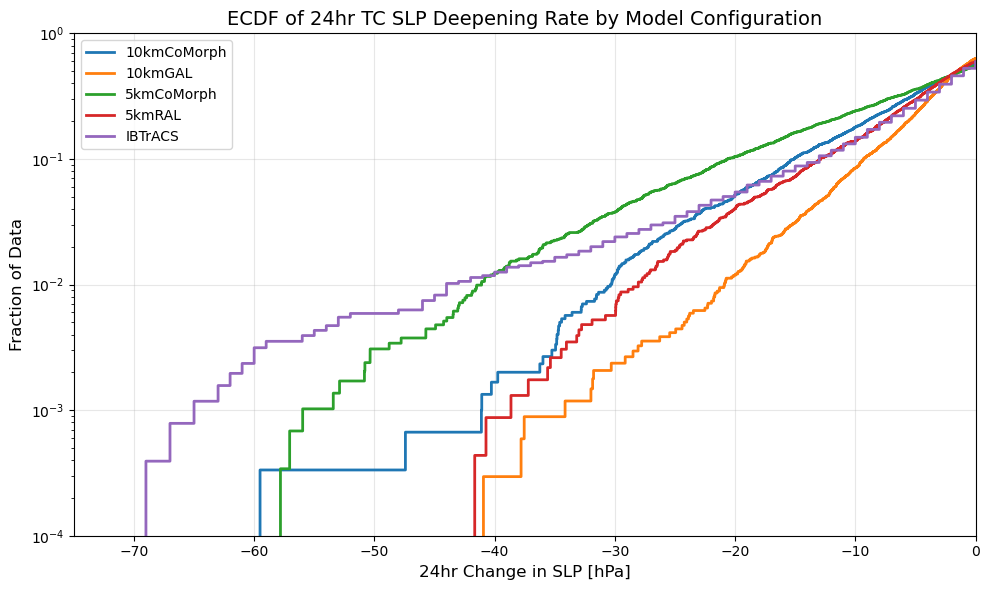

In [52]:
# Single ECDF plot with all model configs
fig, ax = plt.subplots(figsize=(10, 6))

for name, ds in tracks.items():
    # Strip nans from rates 
    rates = ds.pres_ir_24hr.dropna(dim='record')
    # 
    # Plot ECDF
    ax.ecdf(rates, label=name, linewidth=2)

ax.set_xlabel('24hr Change in SLP [hPa]', fontsize=12)
ax.set_ylabel('Fraction of Data', fontsize=12)
ax.set_title('ECDF of 24hr TC SLP Deepening Rate by Model Configuration', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-75,0])
ax.set_yscale('log')
# ax.set_yscale('function', functions=(lambda x: x**0.3, lambda x: x**(1/0.3)))
ax.set_ylim([0.0001,1])
plt.tight_layout()
plt.show()

In [48]:
cm5_si = huracanpy.trackswhere(cm5, cm5.track_id, lambda x:(x.lon.min()>20) & (x.lon.max() < 135))

In [51]:
cm5_si.track_id.hrcn.nunique()

37

In [52]:
cm10 = tracks['10kmCoMorph']

In [54]:
cm10.where(cm10.track_id == 0, drop=True)

<xarray.Dataset> Size: 2kB
Dimensions:       (record: 15)
Dimensions without coordinates: record
Data variables: (12/14)
    track_id      (record) float64 120B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    i             (record) float64 120B 816.0 808.0 801.0 ... 811.0 832.0 857.0
    j             (record) float64 120B 756.0 750.0 744.0 ... 624.0 584.0 561.0
    lon           (record) float64 120B 114.8 113.7 112.7 ... 114.1 117.1 120.6
    lat           (record) float64 120B -19.08 -19.64 -20.2 ... -35.2 -37.36
    psl_min       (record) float64 120B 950.7 957.5 965.2 ... 997.3 994.5 987.5
    ...            ...
    wind_max_925  (record) float64 120B 57.38 54.41 48.0 ... 31.34 23.03 37.16
    wind_max_850  (record) float64 120B 53.63 50.78 46.47 ... 30.09 27.69 35.59
    rh_avg_850    (record) float64 120B 67.02 67.91 77.81 ... 79.66 83.11 75.76
    time          (record) datetime64[ns] 120B 2020-02-01T06:00:00 ... 2020-0...
    wind_ir_24hr  (record) float64 120B nan nan nan nan ... -14.23 -15.56 -1.128
    pres_ir_24hr  (record) float64 120B nan nan nan nan ... 19.13 9.39 -1.305